# 🚨 Anomaly Detection using DBSCAN

Detect outliers (noise points) using DBSCAN clustering.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

In [2]:
# Create synthetic dataset
X, _ = make_blobs(n_samples=300, centers=2, cluster_std=1.0, random_state=42)

# Add some random noise (outliers)
rng = np.random.RandomState(42)
noise = rng.uniform(low=-10, high=10, size=(20, 2))

X = np.vstack([X, noise])

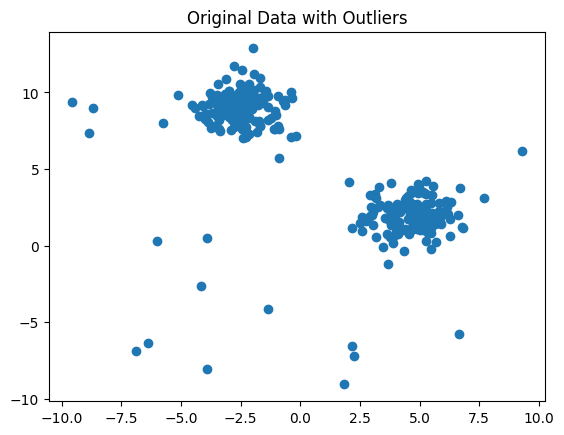

In [3]:
plt.scatter(X[:, 0], X[:, 1])
plt.title("Original Data with Outliers")
plt.show()

In [4]:
# DBSCAN is distance-based → scaling is important
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
# eps = radius
# min_samples = minimum points to form dense region
model = DBSCAN(eps=0.5, min_samples=5)

labels = model.fit_predict(X_scaled)

In [6]:
# In DBSCAN:
# label = -1 → noise (anomaly)

anomalies = X[labels == -1]
normal_points = X[labels != -1]

print("Number of anomalies:", len(anomalies))

Number of anomalies: 15


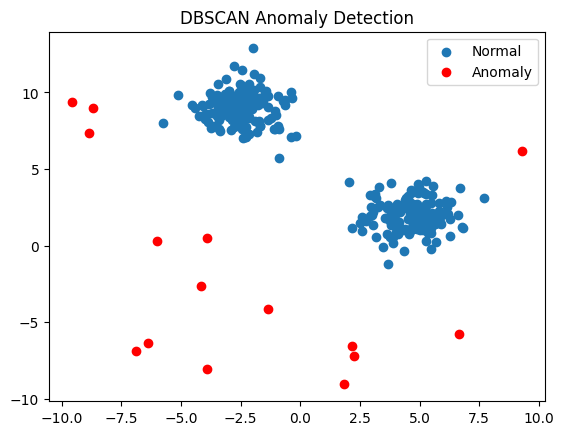

In [7]:
plt.scatter(normal_points[:, 0], normal_points[:, 1], label="Normal")
plt.scatter(anomalies[:, 0], anomalies[:, 1], color='red', label="Anomaly")

plt.title("DBSCAN Anomaly Detection")
plt.legend()
plt.show()

## 🔍 Observations

- DBSCAN automatically detects outliers  
- Points labeled **-1** are anomalies  
- No need to specify number of clusters  

---

## ⚠️ Important

- Sensitive to `eps` parameter  
- Scaling is mandatory  
- Works well for density-based anomalies  

---

## 🧠 One-Line

DBSCAN detects anomalies as points that do not belong to any dense cluster.